In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.constants import codata2010 as cst

from config.plotting import set_plotting_defaults, save_figure
from config.constants import CST_HC, CST_m_e
from config.units import flux_unit
from src.background_photon_density import Starlight, DustLines, CMBOnly, e_to_wvl, wvl_to_e

from src.black_body_radiation import bbr_density
from src.electron_spectrum_parametrization import SpectrumParametrization
from src.klein_nishina import klein_nishina_on_a_given_photon_density_profile

set_plotting_defaults()

In [2]:
e_density_unit = u.cm**(-3)
density_unit = u.cm**(-3) / u.eV

r = 2100 * u.pc
z = 500 * u.pc

photon_energy = np.logspace(-5, 2, 1000) * u.eV
wvl = e_to_wvl(photon_energy)

In [3]:
R_sol = 7e5 * u.km
def stellar_density(e1, r1, T1=10.25e3 * u.K, R1=5.3*R_sol):
    """
    Calculate energy density of stellar photons density at a given point
    :param e1: [eV], energy
    :param r1: [pc], distance
    :param T1: (optional) [K], stellar temperature
    :param R1: (optional) [km], stellar radius
    :return: e.dN/de [e_density_unit]
    Note: 1/4 multiplier is connected to the fact that the source is spherical
    """
    return (1/4 * e1 * bbr_density(e1, T1) * (R1 / r1)**2).to(e_density_unit)

In [4]:
radii = np.array([1e-2, 5e-2, 25e-2]) * u.pc

d_single_star = []
for r_x in radii:
    d_single_star.append(stellar_density(photon_energy, r_x).to(e_density_unit))

d_single_star = np.array(d_single_star)

In [5]:
def wvl_to_e_dl(w):
    return wvl_to_e(w * u.um).value

def e_to_wvl_dl(e):
    return e_to_wvl(e * u.eV).value

In [6]:
dustlines = DustLines()
d_dust = (photon_energy * dustlines.density_e(photon_energy, r, z)).to(e_density_unit)

stars = Starlight()
d_stars = (photon_energy * stars.density_e(photon_energy, r, z)).to(e_density_unit)

cmb = CMBOnly()
d_cmb = (photon_energy * cmb.density_e(photon_energy, .0)).to(e_density_unit)

/home/maxkl/miniforge3/envs/am3/lib/python3.12/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


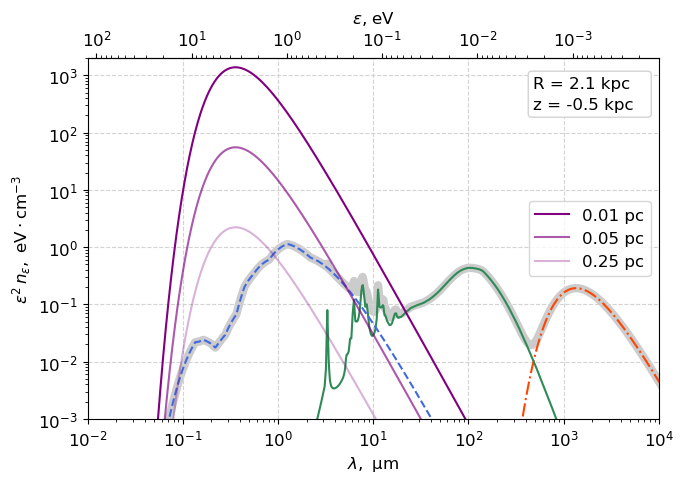

In [15]:
from src.black_body_radiation import bbr_density

ax21 = plt.subplot(1, 1, 1)
ax21.loglog(wvl, photon_energy * d_cmb, color='orangered', linestyle='dashdot')
ax21.loglog(wvl, photon_energy * d_dust, color='seagreen', linestyle='solid')
ax21.loglog(wvl, photon_energy * d_stars, color='royalblue', linestyle='dashed')
ax21.loglog(wvl, photon_energy * (d_cmb + d_dust + d_stars),
            zorder=0, color='black', linewidth=6, alpha=.2)
# plt.scatter(x, y)  # to compare with [POPESCU et al., 2017] at R=1kpc, Z=0kpc

ax21.text(
    0.78, 0.95,              # X, Y in axis fraction (0–1)
    "R = 2.1 kpc   \n"
    "z = -0.5 kpc",
    transform=ax21.transAxes,  # So coordinates are relative to the plot area
    fontsize=12,
    linespacing=1.5,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.3,rounding_size=0.2',
        facecolor='white', edgecolor='lightgray',
    )
)

for i in range(len(radii)):
    ax21.plot(wvl, photon_energy * d_single_star[i], color='purple', alpha=1 - 0.35 * i, label=radii[i])

ax21.set_ylim(1e-3, 2e3)
ax21.set_ylabel(r"$\epsilon^2\,n_\epsilon,~\mathrm{eV \cdot cm^{-3}}$")
ax21.set_xlim(1e-2, 1e4)
ax21.set_xlabel(r"$\lambda,~\mathrm{\mu m}$")

ax22 = ax21.secondary_xaxis('top', functions=(wvl_to_e_dl, e_to_wvl_dl))
ax22.set_xlabel(r"$\epsilon$, eV")

plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# calculate electron scattering

gamma_ray_energy = np.logspace(4, 15, 100) * u.eV
electron_energy = np.logspace(6, 15, 2000) * u.eV
gammas = electron_energy / CST_m_e

d_ref = stellar_density(photon_energy, 0.1 * u.pc) / photon_energy

plt.figure(figsize=(10, 3.5))

electron_spectrum = SpectrumParametrization(n0=1e34 / u.eV,  # number of ejected particles dN/dE
                                            e0=1e12 * u.eV,  # initial reference energy (1 TeV)
                                            eta0=0.0, p0=2.0, k10=-6.0, k20=3.0)
ans = []
for i, gamma in enumerate(gammas):
    dn_de = klein_nishina_on_a_given_photon_density_profile(g1=gamma, e1=gamma_ray_energy,
                                                            e2=photon_energy, bg_phot_density=d_ref,
                                                            if_norm=False)
    e2_dn_de = (gamma_ray_energy**2 * dn_de).to(u.eV/u.s)
    ans.append(e2_dn_de.value)

<Figure size 1000x350 with 0 Axes>

In [9]:
# ZHAO upper limits SINGLE SOURCE
x = [1781.0713709261797, 5602.870237941304, 17188.618773998325, 54754.48235568747, 170098.0999984451] * u.MeV
y = [1.6150698614290255e-13, 1.516657177692803e-13, 5.007935137672472e-13, 5.332889480766019e-13, 1.7334357928430776e-12] * flux_unit

0.0002 pc


(1e-14, 1e-11)

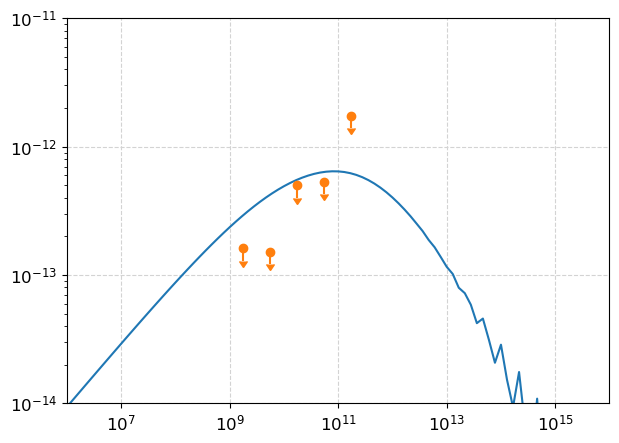

In [10]:
ans = np.array(ans) * u.eV/u.s

dist = 6.1 * u.kpc
area = 4 * np.pi * dist**2

lg_electron_energy = np.log10(electron_energy.value)
total_flux = (np.trapezoid(ans.T * electron_energy * electron_spectrum.dn_de0(electron_energy), lg_electron_energy) / area).to(flux_unit)

r_min = 10000 * R_sol
print(f"{r_min.to(u.pc):.1g}")
nebula_lifetime = 1000 * u.yr


total_flux_adjusted = total_flux * (1 * u.pc)**2 / (r_min * cst.c * nebula_lifetime)

plt.loglog(gamma_ray_energy, total_flux_adjusted.to(flux_unit))
plt.errorbar(x.to(u.eV), y, yerr=0.2 * y, uplims=True, linestyle=None, fmt='o')
plt.xlim(1e6, 1e16)
plt.ylim(1e-14, 1e-11)